<a href="https://colab.research.google.com/github/suyon0416/26-2_ESAA_YB/blob/main/YB_1009(2)_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성

from sklearn.metrics import confusion_matrix

# 실제값(y)과 예측값(y_pred)을 이용해 오차 행렬 생성
conf_matrix = confusion_matrix(y, y_pred)
print("오차 행렬:")
print(conf_matrix)

오차 행렬:
[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [3]:
# 정확도: 전체 예측 데이터 중에서 모델이 실제값과 일치하게 맞춘 비율
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)
print(f"정확도: {accuracy:.4f}")

정확도: 0.9121


**정밀도의 개념을 설명하고, 정밀도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [4]:
# 정밀도: 모델이 양성(1)이라고 예측한 것 중에서 실제 양성인 데이터의 비율

from sklearn.metrics import precision_score

precision = precision_score(y, y_pred)
print(f"정밀도: {precision:.4f}")

정밀도: 0.9010


**재현율의 개념을 설명하고, 재현율을 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [5]:
# 재현율: 실제 양성(1)인 데이터 중에서 모델이 양성으로 올바르게 찾아낸 비율

from sklearn.metrics import recall_score

recall = recall_score(y, y_pred)
print(f"재현율: {recall:.4f}")

재현율: 0.8585


**F1 score의 개념을 설명하고, F1 스코어를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [6]:
# F1 score: 정밀도(Precision)와 재현율(Recall)의 조화 평균을 구한 값

from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print(f"F1 스코어: {f1:.4f}")

F1 스코어: 0.8792


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [11]:
from sklearn.preprocessing import Binarizer

# Binarizer를 이용해 임계값 설정 (예시로 0.9 기준 적용)
pred_proba = model_lor.predict_proba(X)
binarizer = Binarizer(threshold=0.9)
y_pred2 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1, 1))


In [12]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기

print("오차 행렬:")
print(confusion_matrix(y, y_pred2))
print(f"정확도: {accuracy_score(y, y_pred2):.4f}")
print(f"정밀도: {precision_score(y, y_pred2):.4f}")
print(f"재현율: {recall_score(y, y_pred2):.4f}")
print(f"F1 Score: {f1_score(y, y_pred2):.4f}")

오차 행렬:
[[356   1]
 [ 73 139]]
정확도: 0.8699
정밀도: 0.9929
재현율: 0.6557
F1 Score: 0.7898


**ROC 곡선 시각화**

In [14]:
from sklearn.metrics import roc_curve

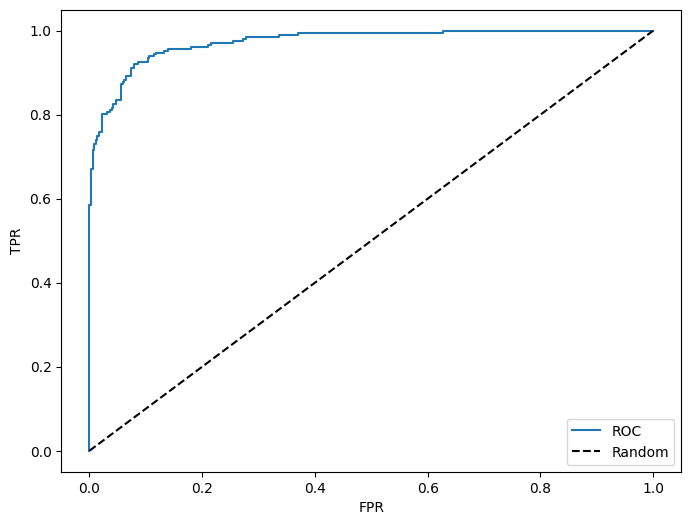

In [15]:
import matplotlib.pyplot as plt

# FPR, TPR 구하기
pred_proba_c1 = model_lor.predict_proba(X)[:, 1]
fprs, tprs, thresholds = roc_curve(y, pred_proba_c1)

# ROC 곡선 그리기
plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, label='ROC')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [16]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y, pred_proba_c1)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9741


개념 및 알 수 있는 점
-  ROC 곡선 아래의 면적(Area Under Curve)을 의미하며, 모델의 전반적인 이진 분류 성능을 나타낸다.

- 값이 1에 가까울수록 모델이 양성과 음성을 구별하는 변별력이 완벽에 가깝게 우수하다는 것을 뜻한다.